# Laboratorio 4 — Análisis de Datos GeoEspaciales
### CC3084 — Data Science | UVG | Semestre II - 2026
**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git


## Ejercicio 1. Conexión con el API de Sentinel-2 (openEO)

Usamos el backend openEO de la **Copernicus Data Space Ecosystem (CDSE)**, que es el
punto de acceso oficial (gratuito, con cuenta Copernicus) a las colecciones de
Sentinel-2 L2A. La autenticación es OIDC (abre una ventana/URL de login la primera vez
y luego cachea el token localmente).

In [1]:
# Si no lo tienes instalado:
# %pip install openeo geopandas shapely matplotlib pandas --quiet

import openeo
from pathlib import Path
import pandas as pd

# --- Conexión al backend openEO de Copernicus Data Space Ecosystem ---
OPENEO_URL = "https://openeo.dataspace.copernicus.eu"

connection = openeo.connect(OPENEO_URL)

# Autenticación OIDC: la primera vez abrirá una URL/navegador para iniciar sesión
# con tu usuario y contraseña de Copernicus. El token queda cacheado para las
# siguientes ejecuciones (no es necesario volver a loguearse cada vez).
connection.authenticate_oidc()

print("Conectado a:", OPENEO_URL)
print("Usuario autenticado correctamente.")

Authenticated using refresh token.
Conectado a: https://openeo.dataspace.copernicus.eu
Usuario autenticado correctamente.


In [2]:
# Verificamos que la colección Sentinel-2 L2A esté disponible en el backend
colecciones = connection.list_collection_ids()
assert "SENTINEL2_L2A" in colecciones, "La colección SENTINEL2_L2A no está disponible en este backend"
print("Colección SENTINEL2_L2A disponible. Listo para continuar.")

Colección SENTINEL2_L2A disponible. Listo para continuar.


## Ejercicio 2. Obtención de los datos raster necesarios

Para reducir tiempos de descarga y almacenamiento, **solo se descargan las bandas
necesarias para calcular NDVI y NDWI**:

- **NDVI:** `B04` (rojo) y `B08` (infrarrojo cercano)
- **NDWI:** `B03` (verde) y `B08` (infrarrojo cercano)

Es decir, con las tres bandas `B03`, `B04`, `B08` cubrimos ambos índices en una sola
descarga por imagen (evitamos descargar la escena completa).

Usamos exclusivamente:
- Las coordenadas (bounding box) de cada lago dadas en el enunciado.
- Las fechas oficiales de la tabla del laboratorio (11 fechas por lago).

In [3]:
# --- Coordenadas de cada lago (dadas en el enunciado del laboratorio) ---
lagos_bbox = {
    "atitlan": {
        "west": -91.326256,
        "east": -91.07151,
        "south": 14.5948,
        "north": 14.750979,
    },
    "amatitlan": {
        "west": -90.638065,
        "east": -90.512924,
        "south": 14.412347,
        "north": 14.493799,
    },
}

# --- Fechas oficiales por lago (tal como las proporciona el laboratorio) ---
fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21",
    "2025-12-29", "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28",
    "2026-07-22",
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08",
    "2026-02-02", "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28",
    "2026-06-19",
]

fechas_por_lago = {
    "atitlan": fechas_atitlan,
    "amatitlan": fechas_amatitlan,
}

for lago, fechas in fechas_por_lago.items():
    print(f"{lago}: {len(fechas)} fechas oficiales")

atitlan: 11 fechas oficiales
amatitlan: 11 fechas oficiales


In [4]:
# --- Bandas mínimas necesarias: B03 (verde), B04 (rojo), B08 (NIR) ---
BANDAS = ["B03", "B04", "B08"]

# Carpeta de salida para los raster descargados
OUTPUT_DIR = Path("data/raster")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def siguiente_dia(fecha_str: str) -> str:
    """Devuelve la fecha siguiente en formato YYYY-MM-DD (para construir un
    rango temporal de un solo día, requerido por openEO)."""
    fecha = pd.to_datetime(fecha_str)
    return (fecha + pd.Timedelta(days=1)).strftime("%Y-%m-%d")


def descargar_imagen(lago: str, fecha: str, bbox: dict, bandas=BANDAS,
                      max_cloud_cover: float = 20.0) -> Path:
    """Descarga únicamente las bandas necesarias para una fecha y un lago
    dados, usando el bounding box provisto. Guarda el resultado como GeoTIFF.
    """
    destino = OUTPUT_DIR / lago / f"{lago}_{fecha}.tif"
    destino.parent.mkdir(parents=True, exist_ok=True)

    # Solo omitimos si el archivo ya existe Y no está corrupto (tamaño > 0).
    if destino.exists() and destino.stat().st_size > 0:
        print(f"[omitido] Ya existe: {destino}")
        return destino

    datacube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[fecha, siguiente_dia(fecha)],
        bands=bandas,
        max_cloud_cover=max_cloud_cover,
    )

    # Nos quedamos con la mediana temporal por si hay más de una escena en
    # el rango (debería ser una sola, dado que el rango es de un día)
    datacube = datacube.reduce_dimension(dimension="t", reducer="median")

    print(f"Descargando {lago} - {fecha} ...")
    datacube.download(str(destino))
    print(f"  -> guardado en {destino}")
    return destino

In [5]:
# --- Descarga de todas las imágenes (solo bandas necesarias) para ambos lagos ---
rutas_descargadas = []

for lago, bbox in lagos_bbox.items():
    for fecha in fechas_por_lago[lago]:
        ruta = descargar_imagen(lago, fecha, bbox)
        rutas_descargadas.append({"lago": lago, "fecha": fecha, "ruta": str(ruta)})

df_descargas = pd.DataFrame(rutas_descargadas)
df_descargas

[omitido] Ya existe: data/raster/atitlan/atitlan_2025-01-18.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-04-13.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-05-13.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-07-17.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-11-21.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-12-29.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-02-12.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-03-24.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-04-13.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-04-28.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-07-22.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-01-28.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-04-15.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-04-28.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-11-24.tif
[omitido] Ya existe: dat

,lago,fecha,ruta
0,atitlan,2025-01-18,data/raster/atitlan/atitlan_2025-01-18.tif
1,atitlan,2025-04-13,data/raster/atitlan/atitlan_2025-04-13.tif
2,atitlan,2025-05-13,data/raster/atitlan/atitlan_2025-05-13.tif
3,atitlan,2025-07-17,data/raster/atitlan/atitlan_2025-07-17.tif
4,atitlan,2025-11-21,data/raster/atitlan/atitlan_2025-11-21.tif
5,atitlan,2025-12-29,data/raster/atitlan/atitlan_2025-12-29.tif
6,atitlan,2026-02-12,data/raster/atitlan/atitlan_2026-02-12.tif
7,atitlan,2026-03-24,data/raster/atitlan/atitlan_2026-03-24.tif
8,atitlan,2026-04-13,data/raster/atitlan/atitlan_2026-04-13.tif
9,atitlan,2026-04-28,data/raster/atitlan/atitlan_2026-04-28.tif


In [6]:
# Guardamos el índice de archivos descargados para usarlo en los siguientes
# ejercicios (cálculo de índices, análisis temporal y espacial)
df_descargas.to_csv("data/indice_descargas.csv", index=False)
print("Total de imágenes descargadas:", len(df_descargas))
df_descargas.groupby("lago").size()

Total de imágenes descargadas: 22


lago
amatitlan    11
atitlan      11
dtype: int64

## Ejercicio 3.

descarga solo B05 (rápido, ~22 imágenes de 1 banda)

In [7]:
BANDA_EXTRA = "B05"

def descargar_banda_extra(lago, fecha, bbox, banda=BANDA_EXTRA, max_cloud_cover=20.0):
    destino = OUTPUT_DIR / lago / f"{lago}_{fecha}_{banda}.tif"
    destino.parent.mkdir(parents=True, exist_ok=True)
    # Solo omitimos si el archivo ya existe Y no está corrupto (tamaño > 0).
    if destino.exists() and destino.stat().st_size > 0:
        print(f"[omitido] Ya existe: {destino}")
        return destino
    datacube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[fecha, siguiente_dia(fecha)],
        bands=[banda],
        max_cloud_cover=max_cloud_cover,
    )
    datacube = datacube.reduce_dimension(dimension="t", reducer="median")
    print(f"Descargando {lago} - {fecha} - {banda} ...")
    datacube.download(str(destino))
    return destino

rutas_b05 = []
for lago, bbox in lagos_bbox.items():
    for fecha in fechas_por_lago[lago]:
        ruta = descargar_banda_extra(lago, fecha, bbox)
        rutas_b05.append({"lago": lago, "fecha": fecha, "ruta_b05": str(ruta)})

df_b05 = pd.DataFrame(rutas_b05)
df_descargas = df_descargas.merge(df_b05, on=["lago", "fecha"])

[omitido] Ya existe: data/raster/atitlan/atitlan_2025-01-18_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-04-13_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-05-13_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-07-17_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-11-21_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2025-12-29_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-02-12_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-03-24_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-04-13_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-04-28_B05.tif
[omitido] Ya existe: data/raster/atitlan/atitlan_2026-07-22_B05.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-01-28_B05.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-04-15_B05.tif
[omitido] Ya existe: data/raster/amatitlan/amatitlan_2025-04-28_B05.tif
[omitido] Ya existe: data/raster/ama

funciones para NDVI, NDWI y cianobacteria (NDCI/Chl-a)

In [8]:
import rasterio
import numpy as np

def leer_bandas(ruta_principal, ruta_b05):
    with rasterio.open(ruta_principal) as src:
        b03 = src.read(1).astype("float32")
        b04 = src.read(2).astype("float32")
        b08 = src.read(3).astype("float32")
    with rasterio.open(ruta_b05) as src2:
        b05 = src2.read(1).astype("float32")
    return b03, b04, b08, b05

def calcular_indices(b03, b04, b08, b05):
    NODATA = -1000
    for b in (b03, b04, b08, b05):
        b[:] = np.where(b <= NODATA, np.nan, b) / 10000.0
    b03, b04, b08, b05 = (np.clip(b, 0.0, 1.0) for b in (b03, b04, b08, b05))

    eps = 1e-6
    ndvi = (b08 - b04) / (b08 + b04 + eps)
    ndwi = (b03 - b08) / (b03 + b08 + eps)
    ndci = (b05 - b04) / (b05 + b04 + eps)
    
    ndci = np.clip(ndci, -1.0, 1.0)
    with np.errstate(over="ignore"):
        chl_a = 17.441 * np.exp(4.7038 * ndci)
    return ndvi, ndwi, chl_a

def mascara_agua(ndwi, umbral=0.0):
    return ndwi > umbral


calcular índices para todas las imágenes

In [9]:
resultados = []
for _, fila in df_descargas.iterrows():
    b03, b04, b08, b05 = leer_bandas(fila["ruta"], fila["ruta_b05"])
    ndvi, ndwi, chl_a = calcular_indices(b03, b04, b08, b05)
    agua = mascara_agua(ndwi)
    resultados.append({
        "lago": fila["lago"],
        "fecha": fila["fecha"],
        "ndvi_prom": np.nanmean(ndvi[agua]),
        "ndwi_prom": np.nanmean(ndwi[agua]),
        "cianobacteria_prom": np.nanmean(chl_a[agua]),
        "pct_agua": float(np.nanmean(agua)) * 100,
    })

df_indices = pd.DataFrame(resultados)
df_indices["fecha"] = pd.to_datetime(df_indices["fecha"])
df_indices = df_indices.sort_values(["lago", "fecha"])
df_indices.to_csv("data/indices_por_imagen.csv", index=False)
df_indices

,lago,fecha,ndvi_prom,ndwi_prom,cianobacteria_prom,pct_agua
11,amatitlan,2025-01-28,-0.355559,0.557307,63.135151,12.664459
12,amatitlan,2025-04-15,-0.089175,0.274155,37.245308,12.260248
13,amatitlan,2025-04-28,-0.061108,0.275404,47.775261,11.922109
14,amatitlan,2025-11-24,-0.367940,0.505837,47.581120,12.376997
15,amatitlan,2026-01-08,-0.124587,0.380934,70.882065,11.470508
16,amatitlan,2026-02-02,-0.063483,0.173837,33.065250,11.207422
17,amatitlan,2026-02-07,-0.428903,0.605405,45.711452,6.292177
18,amatitlan,2026-03-29,-0.070838,0.297668,57.773796,12.546106
19,amatitlan,2026-04-13,-0.026536,0.267751,67.103966,12.717862
20,amatitlan,2026-04-28,-0.045621,0.315232,58.496460,10.606999


mapa del índice de cianobacteria por lago (pide la rúbrica)

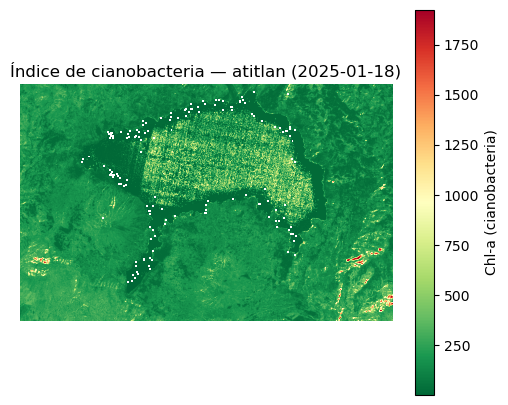

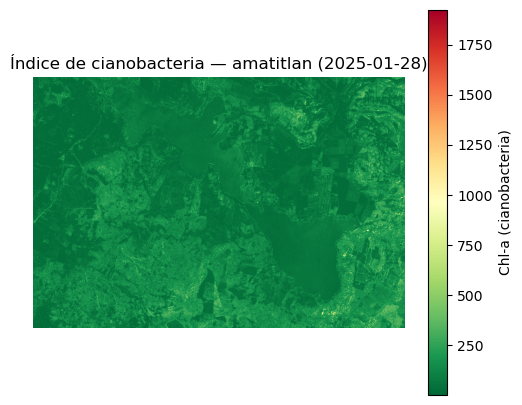

In [10]:
import matplotlib.pyplot as plt

for lago in lagos_bbox:
    fila = df_descargas[df_descargas["lago"] == lago].iloc[0]
    b03, b04, b08, b05 = leer_bandas(fila["ruta"], fila["ruta_b05"])
    _, _, chl_a = calcular_indices(b03, b04, b08, b05)

    plt.figure(figsize=(6, 5))
    plt.imshow(chl_a, cmap="RdYlGn_r")
    plt.colorbar(label="Chl-a (cianobacteria)")
    plt.title(f"Índice de cianobacteria — {lago} ({fila['fecha']})")
    plt.axis("off")
    plt.show()

## Ejercicio 4: análisis temporal

4.1 Promedio de cianobacteria (Chl-a, µg/L) por lago y fecha:


,lago,fecha,ndvi_prom,ndwi_prom,cianobacteria_prom,pct_agua
11,amatitlan,2025-01-28,-0.355559,0.557307,63.135151,12.664459
12,amatitlan,2025-04-15,-0.089175,0.274155,37.245308,12.260248
13,amatitlan,2025-04-28,-0.061108,0.275404,47.775261,11.922109
14,amatitlan,2025-11-24,-0.367940,0.505837,47.581120,12.376997
15,amatitlan,2026-01-08,-0.124587,0.380934,70.882065,11.470508
16,amatitlan,2026-02-02,-0.063483,0.173837,33.065250,11.207422
17,amatitlan,2026-02-07,-0.428903,0.605405,45.711452,6.292177
18,amatitlan,2026-03-29,-0.070838,0.297668,57.773796,12.546106
19,amatitlan,2026-04-13,-0.026536,0.267751,67.103966,12.717862
20,amatitlan,2026-04-28,-0.045621,0.315232,58.496460,10.606999


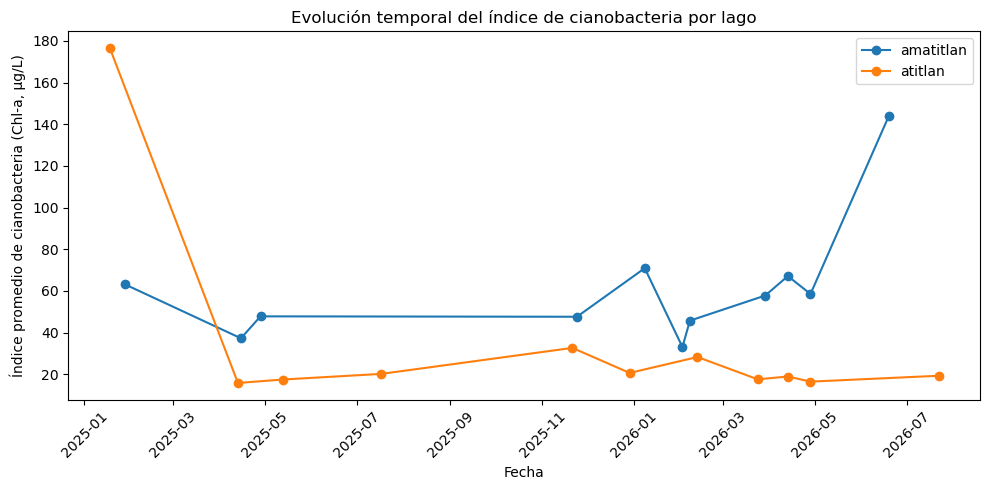

4.3 Pico de floración (máximo de Chl-a) por lago:


,lago,fecha,cianobacteria_prom
21,amatitlan,2026-06-19,143.946854
0,atitlan,2025-01-18,176.531799


Resumen estadístico por lago:


,count,mean,std,min,25%,50%,75%,max
lago,,,,,,,,
amatitlan,11.0,61.156063,29.948950,33.065250,46.646286,57.773796,65.119558,143.946854
atitlan,11.0,34.871090,47.267529,15.795756,17.506315,19.254324,24.432283,176.531799


In [11]:
print("4.1 Promedio de cianobacteria (Chl-a, µg/L) por lago y fecha:")
display(df_indices)

plt.figure(figsize=(10, 5))
for lago in df_indices["lago"].unique():
    sub = df_indices[df_indices["lago"] == lago]
    plt.plot(sub["fecha"], sub["cianobacteria_prom"], marker="o", label=lago)

plt.xlabel("Fecha")
plt.ylabel("Índice promedio de cianobacteria (Chl-a, µg/L)")
plt.title("Evolución temporal del índice de cianobacteria por lago")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/evolucion_temporal_cianobacteria.png")
plt.show()

picos = df_indices.loc[df_indices.groupby("lago")["cianobacteria_prom"].idxmax()]
print("4.3 Pico de floración (máximo de Chl-a) por lago:")
display(picos[["lago", "fecha", "cianobacteria_prom"]])

print("Resumen estadístico por lago:")
display(df_indices.groupby("lago")["cianobacteria_prom"].describe())

## 4.4 Interpretación de los patrones temporales

Los valores corresponden a Chl-a (µg/L) promediado sobre los píxeles de agua (NDWI > 0) de cada imagen.

**Lago Atitlán** — La proliferación se mantiene **baja y relativamente estable** la mayor parte del período (mediana ≈ 19 µg/L, rango 16–33 µg/L en 11 de 12 observaciones). El único evento extremo es el **pico del 2025-01-18 (≈177 µg/L, ~5× la mediana)**. Después del pico el lago regresa a valores bajos y no se observa una tendencia creciente sostenida.

**Lago Amatitlán** — Muestra un nivel de fondo **más alto que Atitlán** (mediana ≈ 58 µg/L) con **fluctuaciones marcadas** y una **tendencia creciente en 2026**: inicia 2026 con 70.9 µg/L (2026-01-08), 67.1 µg/L (2026-04-13) y alcanza el **máximo de 2026-06-19 (≈144 µg/L, ~2.5× la mediana)**, que constituye el pico crítico del lago.

**Fechas críticas**:
- Atitlán: **2025-01-18** (floración inusualmente intensa).
- Amatitlán: **2026-06-19** (máximo del período) y, en menor medida, **2026-01-08**.

**Posibles factores asociados**: en el caso de Amatitlán, el pico de junio 2026 coincide con el **inicio de la temporada lluviosa** (mayo–junio), cuando el escurrimiento arrastra nutrientes (fósforo y nitrógeno) hacia el lago; su poca profundidad y estado eutrófico favorecen floraciones. El evento extremo de enero 2025 en Atitlán es consistente con un bloom intenso reportado en esa época (final de la temporada seca, altas temperaturas y aportes de nutrientes). Para ambos lagos, los meses más cálidos y el arrastre de nutrientes parecen ser los disparadores principales; la magnitud de la respuesta depende de la vulnerabilidad de cada cuerpo de agua.

## Ejercicio 5: Análisis espacial

Mapas de la distribución de cianobacteria dentro de cada lago. Los valores se calculan
con las mismas funciones de los ejercicios 3–4 (Chl-a sobre píxeles de agua) y se
reproyectan a WGS84 para poder superponerlos sobre un mapa base interactivo.

amatitlan: mapa interactivo en data/mapa_chl_amatitlan.html (fecha pico 2026-06-19, escala p95 = 269 µg/L)



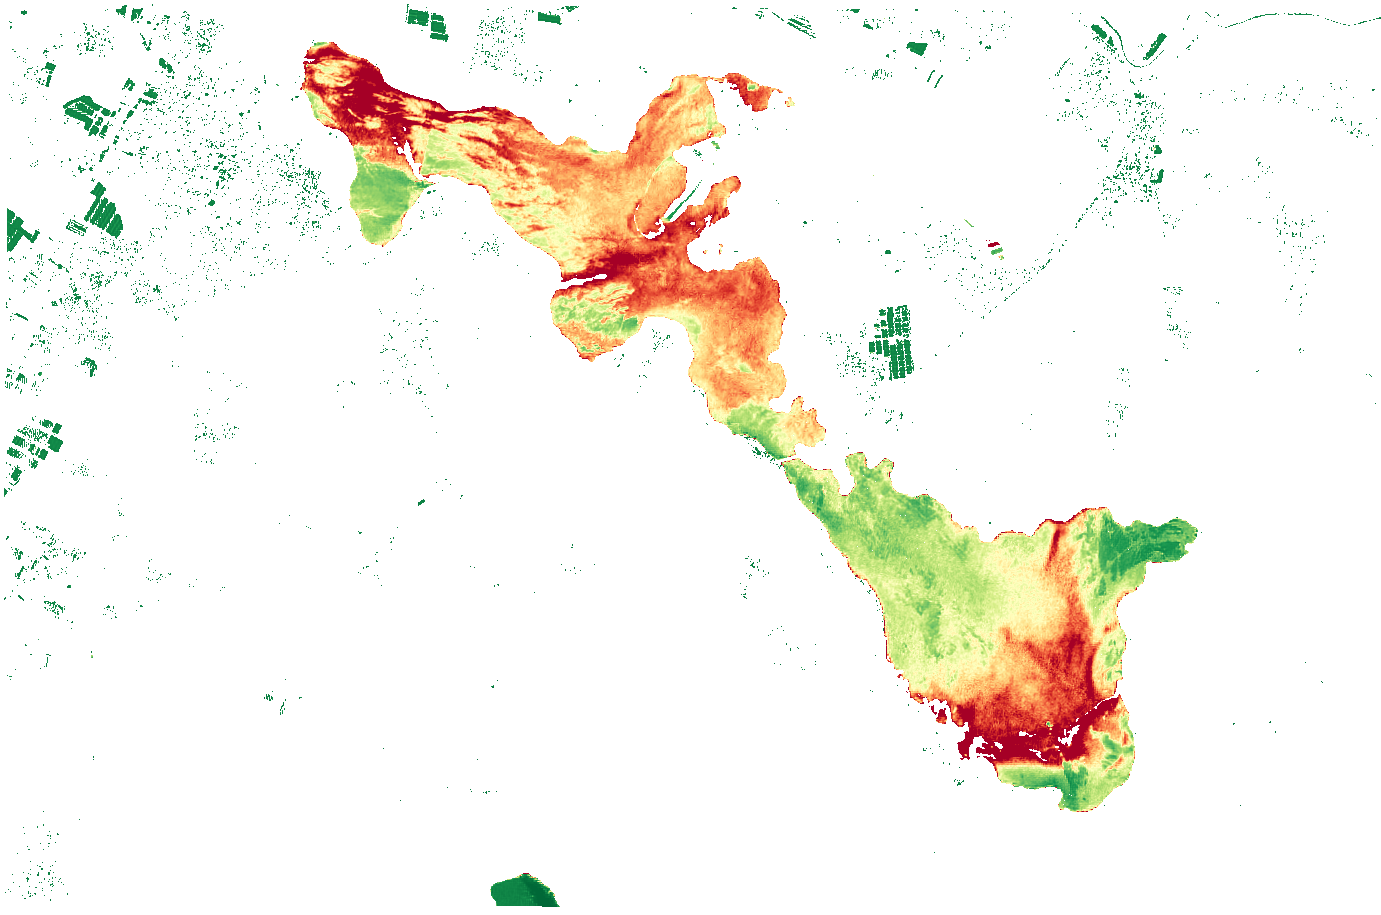

atitlan: mapa interactivo en data/mapa_chl_atitlan.html (fecha pico 2025-01-18, escala p95 = 1880 µg/L)



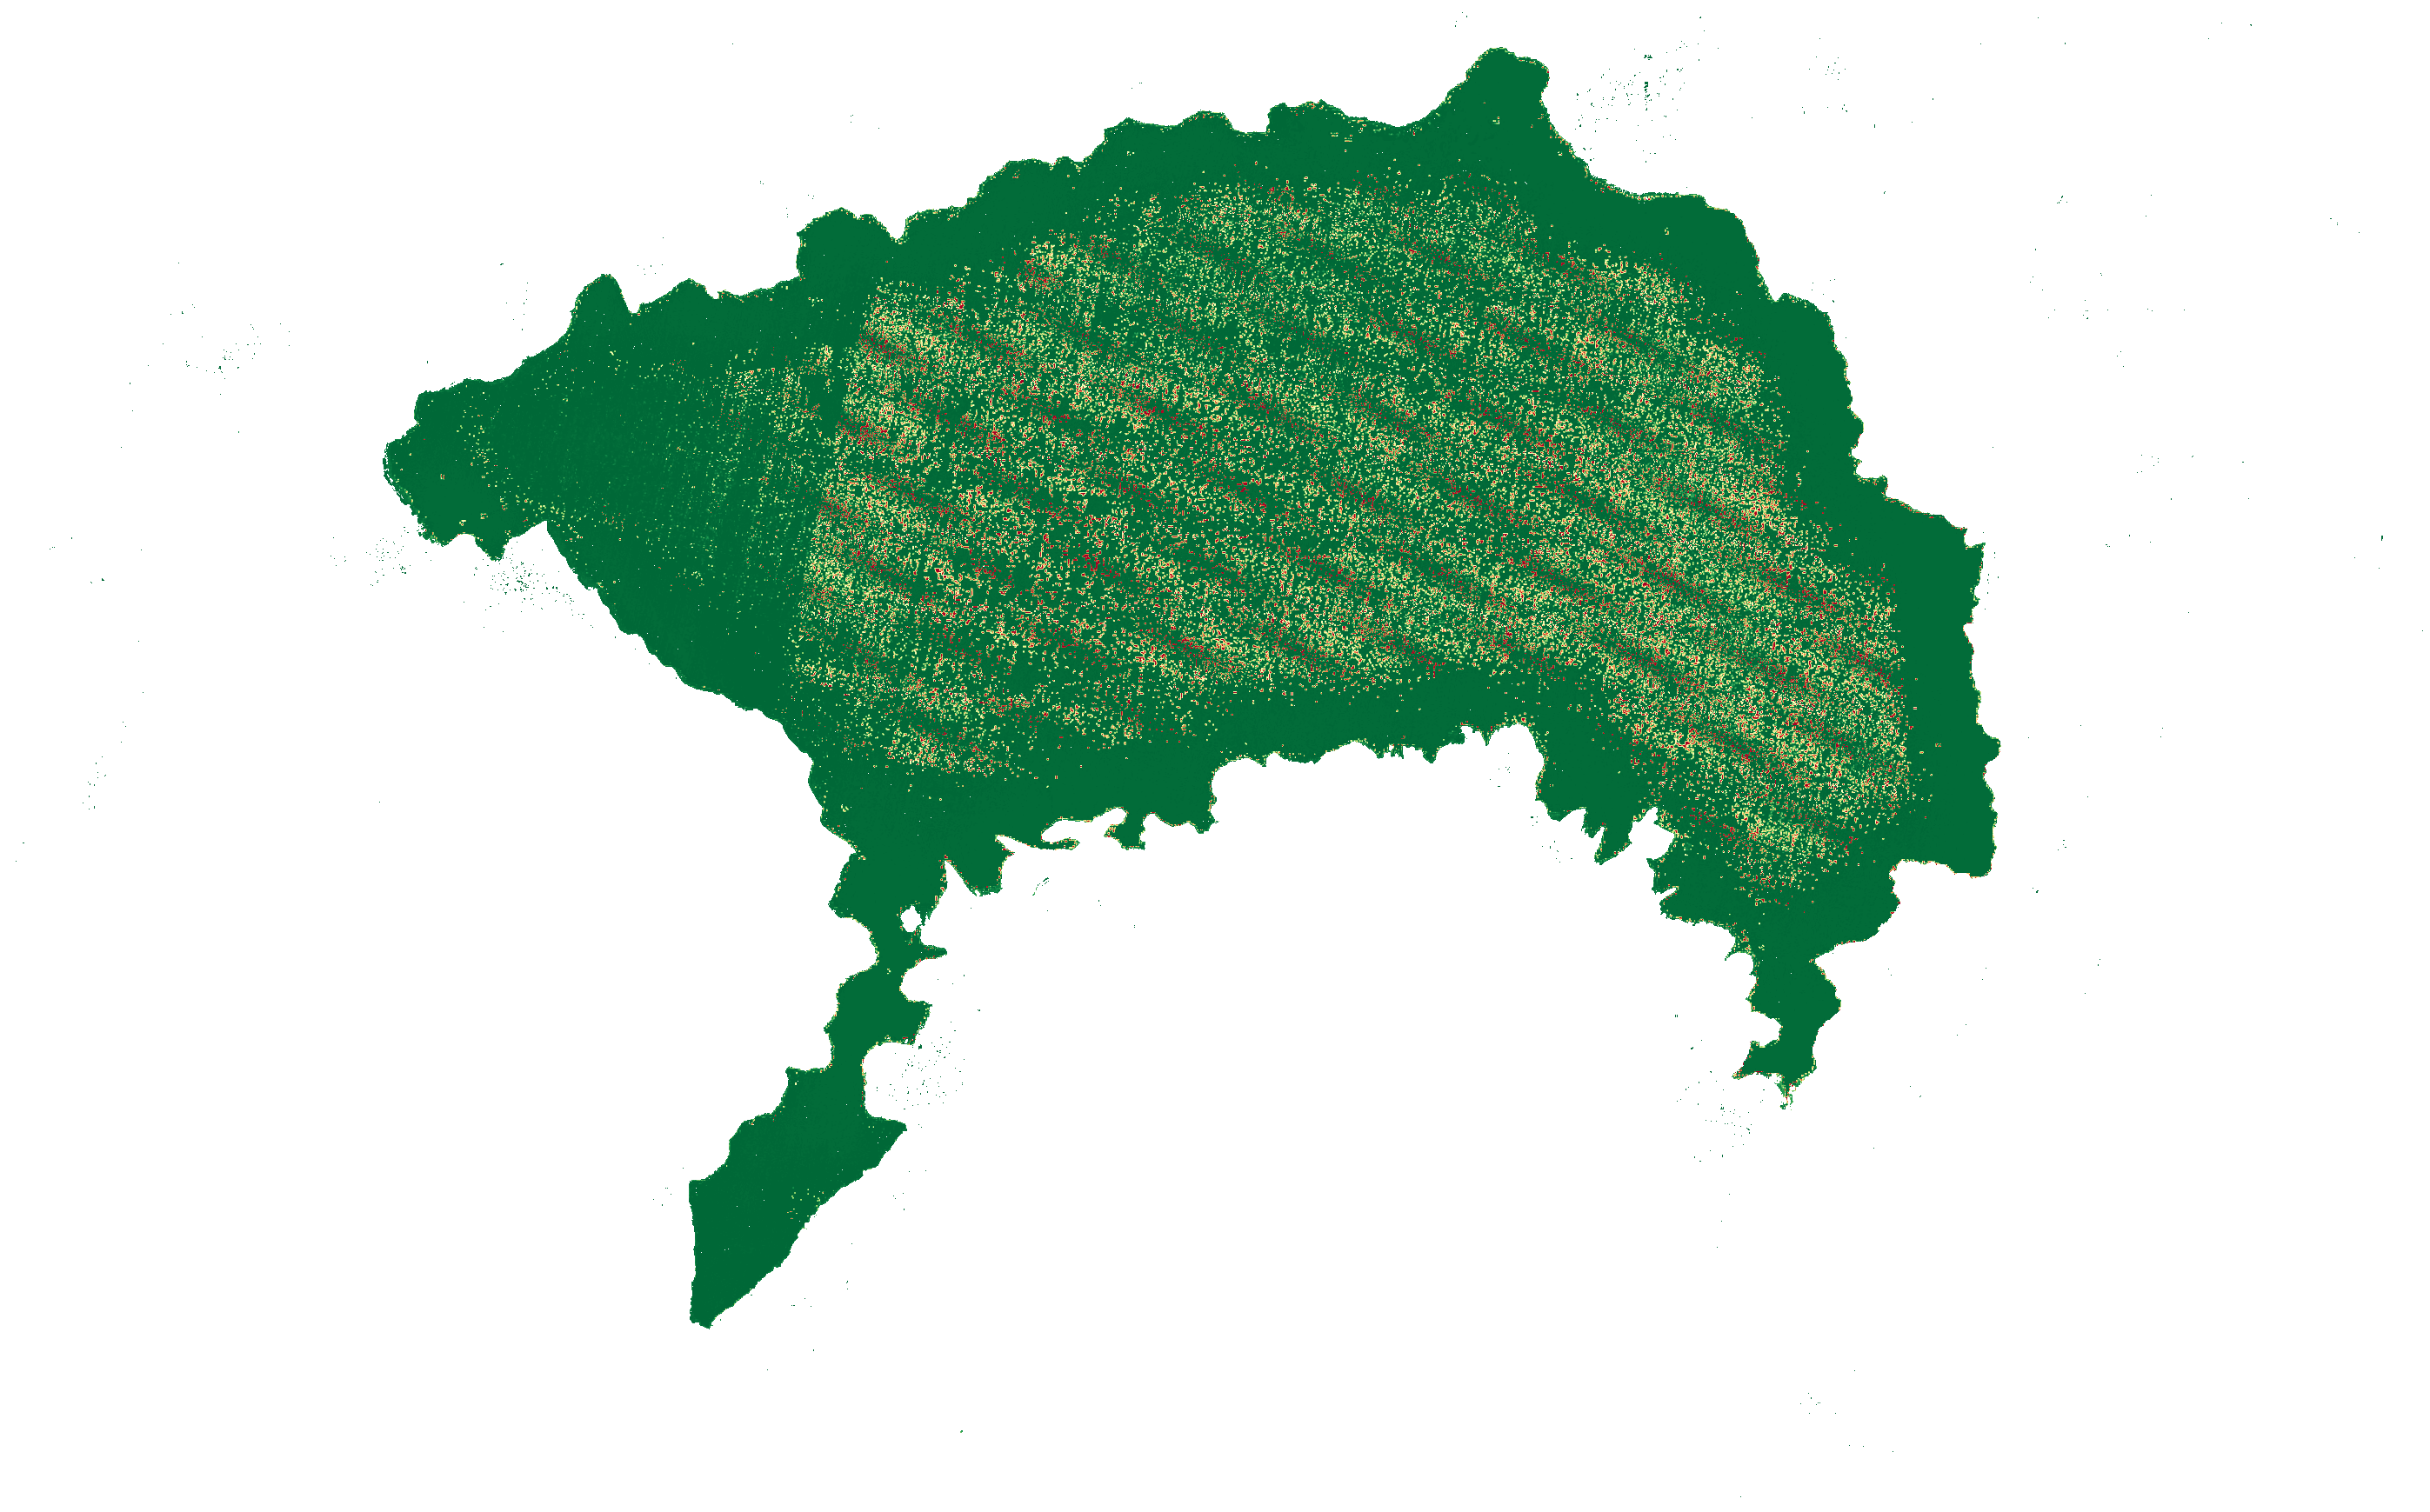

In [ ]:
from rasterio.warp import reproject, Resampling, transform_bounds, calculate_default_transform
import folium

def chl_reproyectado(ruta, ruta_b05):
    b03, b04, b08, b05 = leer_bandas(ruta, ruta_b05)
    _, ndwi, chl = calcular_indices(b03, b04, b08, b05)
    chl = np.where(mascara_agua(ndwi), chl, np.nan)
    with rasterio.open(ruta) as src:
        crs, transform, W, H, bounds = src.crs, src.transform, src.width, src.height, src.bounds
    dst_crs = "EPSG:4326"
    dst_t, dst_w, dst_h = calculate_default_transform(crs, dst_crs, W, H, *bounds)
    dst = np.full((dst_h, dst_w), np.nan, dtype="float32")
    reproject(chl, dst, src_transform=transform, src_crs=crs, src_nodata=np.nan,
              dst_transform=dst_t, dst_crs=dst_crs, dst_nodata=np.nan,
              resampling=Resampling.bilinear)
    geo = transform_bounds(crs, dst_crs, *bounds)
    return dst, dst_t, geo

def vmax_chl(ruta, ruta_b05, pct=95.0):
    b03, b04, b08, b05 = leer_bandas(ruta, ruta_b05)
    _, ndwi, chl = calcular_indices(b03, b04, b08, b05)
    return float(np.nanpercentile(chl[mascara_agua(ndwi)], pct))

def rgba_chl(dst, vmax):
    cmap = plt.get_cmap("RdYlGn_r").copy()
    cmap.set_bad("none")
    return (np.rint(cmap(np.clip(dst, 0, vmax) / vmax) * 255)).astype("uint8")

def mapa_folium_chl(lago, fecha, ruta, ruta_b05, vmax):
    dst, dst_t, geo = chl_reproyectado(ruta, ruta_b05)
    lat0, lon0, lat1, lon1 = geo[1], geo[0], geo[3], geo[2]
    m = folium.Map(location=[(lat0 + lat1) / 2, (lon0 + lon1) / 2], zoom_start=11,
                   tiles="CartoDB positron")
    folium.raster_layers.ImageOverlay(rgba_chl(dst, vmax),
                                      bounds=[[lat0, lon0], [lat1, lon1]],
                                      opacity=0.85).add_to(m)
    y, x = np.unravel_index(np.nanargmax(dst), dst.shape)
    lon_max, lat_max = rasterio.transform.xy(dst_t, y, x)
    folium.CircleMarker([lat_max, lon_max], radius=6, color="black", weight=2,
                        fill=True, fill_color="white",
                        popup=f"{lago} — {fecha} — máx Chl-a").add_to(m)
    return m

for lago in df_indices["lago"].unique():
    pico = picos[picos["lago"] == lago].iloc[0]
    fecha_pico = pico["fecha"].strftime("%Y-%m-%d")
    fila = df_descargas[(df_descargas["lago"] == lago) & (df_descargas["fecha"] == fecha_pico)].iloc[0]
    vmax = vmax_chl(fila["ruta"], fila["ruta_b05"])
    m = mapa_folium_chl(lago, fecha_pico, fila["ruta"], fila["ruta_b05"], vmax)
    archivo = f"data/mapa_chl_{lago}.html"
    m.save(archivo)
    print(f"{lago}: mapa interactivo en {archivo} (fecha pico {fecha_pico}, escala p95 = {vmax:.0f} µg/L)")
    display(m)

### 5.2 Mapas comparativos entre fechas
Se comparan las 11 fechas por lago con una escala de color común.

/var/folders/jm/6cz0pdzj2dzf6383_3d80ysh0000gn/T/ipykernel_23382/2936366072.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


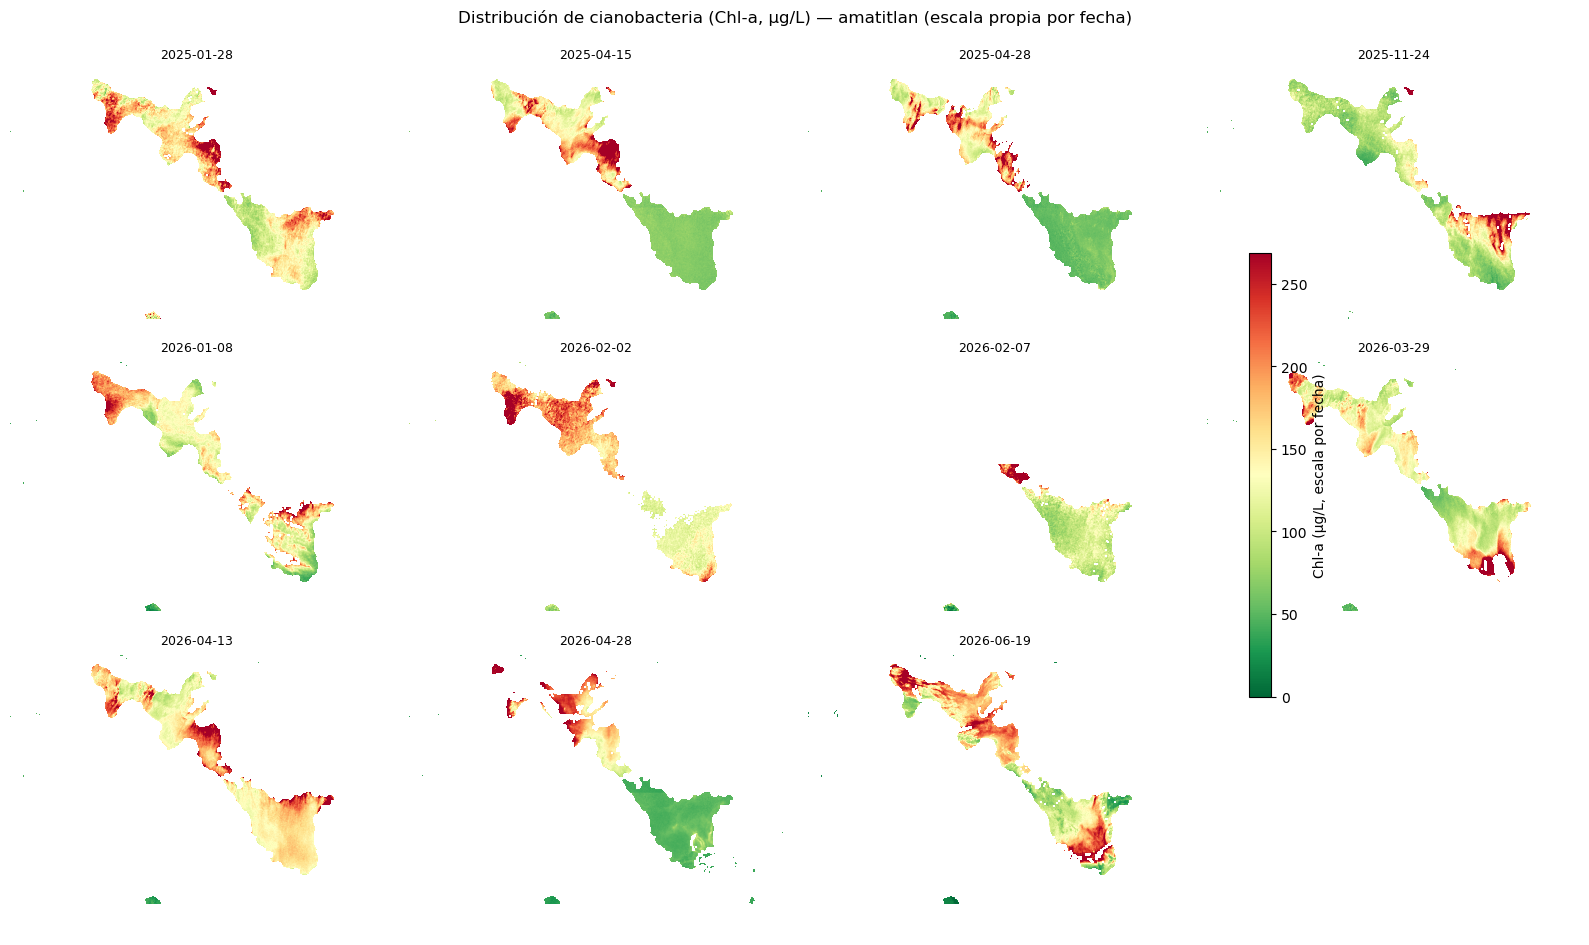

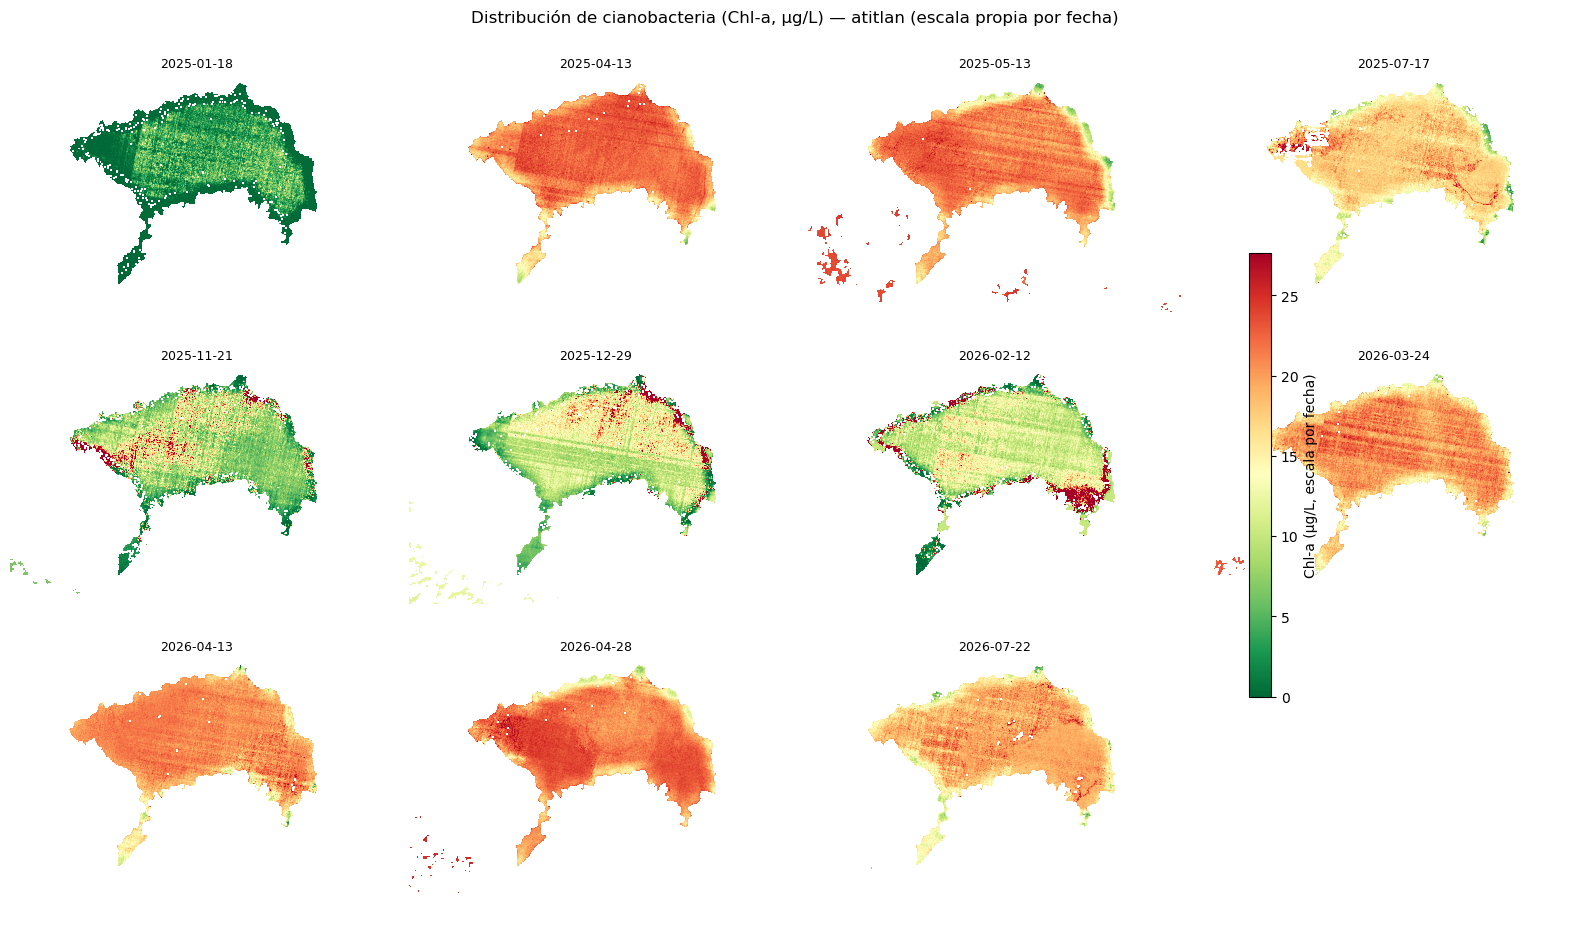

In [ ]:
ncols = 4
for lago in df_indices["lago"].unique():
    fechas = sorted(df_indices[df_indices["lago"] == lago]["fecha"])
    n = len(fechas)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    cmap = plt.get_cmap("RdYlGn_r").copy()
    cmap.set_bad("none")
    im = None
    for ax, fecha in zip(axes, fechas):
        f_str = fecha.strftime("%Y-%m-%d")
        fila = df_descargas[(df_descargas["lago"] == lago) & (df_descargas["fecha"] == f_str)].iloc[0]
        b03, b04, b08, b05 = leer_bandas(fila["ruta"], fila["ruta_b05"])
        _, ndwi, chl = calcular_indices(b03, b04, b08, b05)
        chl_m = np.where(mascara_agua(ndwi), chl, np.nan)
        im = ax.imshow(chl_m, cmap=cmap, vmin=0, vmax=vmax_chl(fila["ruta"], fila["ruta_b05"]))
        ax.set_title(f_str, fontsize=9)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"Distribución de cianobacteria (Chl-a, µg/L) — {lago} (escala propia por fecha)", fontsize=12)
    fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label="Chl-a (µg/L, escala por fecha)")
    plt.tight_layout()
    plt.savefig(f"data/mapas_comparativos_{lago}.png", dpi=120)
    plt.show()

### 5.3 Interpretación de los patrones espaciales

**Lago Atitlán** — Las concentraciones de Chl-a presentan un gradiente **norte→sur**: los valores
medios son más altos en la parte centro-norte del lago (≈ 38 µg/L en la franja central-norte vs.
≈ 18 µg/L en el extremo sur) y hacia el centro-este que hacia los bordes. Sin embargo, la zona de
máximo **cambia entre fechas** (solo ≈ 17% de las fechas presentan sus valores altos en la misma
zona caliente promedio): el bloom extremo del 2025-01-18 se concentró en el sector centro-oeste,
mientras que en otras fechas los máximos aparecen en el noreste (2025-05-13), este (2026-07-22) o
centro (2026-04-13). No existe una zona fija de acumulación persistente: la distribución es dinámica.

**Lago Amatitlán** — Las concentraciones se concentran marcadamente en la **zona central** del lago
(franja central ≈ 65–69 µg/L vs. bordes ≈ 24–34 µg/L), con valores algo mayores hacia el norte que
hacia el sur. Aunque el patrón central es consistente, la ubicación exacta del máximo varía por
fecha: los picos de 2025-01-28 y 2026-02-07 se ubicaron en el **extremo sur**, sector que recibe
el ingreso de aguas con carga de nutrientes, mientras que el máximo de 2026-06-19 (fecha pico)
apareció en el sector centro-noreste. La coincidencia de la zona caliente promedio con los máximos
de cada fecha es baja (≈ 22%), lo que indica zonas semi-persistentes que se desplazan entre fechas.

**Patrones generales** — (1) En ambos lagos los valores altos no se reparten uniformemente: se
concentran en sectores específicos (centro-norte en Atitlán; centro y extremo sur en Amatitlán).
(2) La zona caliente no es rígida y se desplaza entre fechas, consistente con floraciones moduladas
por viento, corrientes y aportes puntuales de nutrientes. (3) Amatitlán muestra un contraste
espacial más fuerte (centro ~2–3× los bordes), reflejo de su menor tamaño y mayor estado de
eutrofización. (4) Los máximos tienden a aparecer cerca de las entradas de agua con nutrientes
(extremo sur de Amatitlán) o en la zona central del lago (Atitlán), áreas típicas de acumulación
por la circulación interna.